# The lift vanished after two weeks

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/novelty-decay/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/novelty-decay/demo.ipynb)

A measured lift is a lift **at an age**. The launch decision is about a population that will
be older than every user in the test, so no scalar summary of the test window is an estimate
of the quantity being decided on.

That much is folklore. This notebook works out the parts that are not:

1. **Three numbers off one curve** - the first-day lift, the pooled window lift and the
   final-week lift differ by 5x on the same data, and none of them is the long-run effect.
2. **A design constant** - how users were let into the test changes the reported lift by 27%
   with no change to the effect, the users, or the test length. It is arithmetic on the
   release calendar, and it runs the *opposite* way to the usual intuition.
3. **The asymptote is the parameter the window never observes** - fitting the decay curve and
   reading off its limit is only reliable when the window is ~8 decay constants long, which
   is exactly when you no longer need the fit. Its $R^2$ points the wrong way down that ladder.
4. **The headline: a decaying lift does not mean the effect decayed.** We construct - exactly,
   not approximately - a world with *no decay in any user* whose lift-by-tenure curve is
   identical to the decay world's, and whose correct long-run answer is **5x larger**. What
   separates them is a column in the table, not a test.
5. **Survivorship** makes the identical estimator fail *upward*, and the obvious retention
   guard is nearly blind to it.
6. **What the fix costs** - a 5% long-term holdout carries 2.29x the MDE of the test that
   shipped the feature, and one holdout carrying several launches is a joint cost whose
   per-launch split the release calendar either permits or forbids outright.

Everything below is computed in this notebook. Nothing is quoted.

## 1. The engine

Three generators and the readouts an experiment publishes. A panel is `n_users` x `T` days;
a user enrolled on day `s` is observed from tenure 0 onward, so the tenures present in the
data depend on the enrollment process.

In [1]:
from __future__ import annotations

from typing import Dict, Optional, Tuple

import numpy as np
from scipy import optimize, stats

TAU0, TAU_INF, LAM, T = 0.10, 0.02, 7.0, 28


def tau_decay(t, tau0=TAU0, tau_inf=TAU_INF, lam=LAM):
    """Effect at tenure t: tau0 on the first day, tau_inf in the limit."""
    return tau_inf + (tau0 - tau_inf) * np.exp(-np.asarray(t, dtype=float) / lam)


def skeleton(n_users, T, enroll):
    s = np.zeros(n_users, dtype=np.int64) if enroll == "bigbang" else (np.arange(n_users) % T)
    tenure = np.arange(T)[None, :] - s[:, None]
    return s.astype(np.int64), tenure, tenure >= 0


def panel_decay(rng, n_users=8400, T=T, enroll="uniform", tau0=TAU0, tau_inf=TAU_INF,
                lam=LAM, sigma=1.0, p_treat=0.5):
    """A GENUINE novelty effect: each user's own effect decays with their own tenure.

    p_treat is a GENERATION-time argument on purpose: relabelling the arms after the
    outcomes are drawn decouples the labels from the applied effect, which reads as a null.
    """
    s, tenure, obs = skeleton(n_users, T, enroll)
    w = (rng.random(n_users) < p_treat).astype(np.int8)
    eff = tau_decay(np.clip(tenure, 0, None), tau0, tau_inf, lam)
    y = rng.normal(0.0, sigma, (n_users, T)) + w[:, None] * eff
    return {"y": np.where(obs, y, np.nan), "w": w, "s": s,
            "tenure": np.where(obs, tenure, -1), "obs": obs, "T": T,
            "truth_long_run": tau_inf}


def pooled_lift(d):
    """The number on the dashboard."""
    y, w = d["y"], d["w"]
    a, b = y[w == 1], y[w == 0]
    na, nb = int(np.isfinite(a).sum()), int(np.isfinite(b).sum())
    se = np.sqrt(np.nanvar(a, ddof=1) / na + np.nanvar(b, ddof=1) / nb)
    return float(np.nanmean(a) - np.nanmean(b)), float(se)


def window_lift(d, lo, hi):
    """Lift over the user-days whose tenure falls in [lo, hi)."""
    cell = (d["tenure"] >= lo) & (d["tenure"] < hi)
    a = d["y"][cell & (d["w"][:, None] == 1)]
    b = d["y"][cell & (d["w"][:, None] == 0)]
    se = np.sqrt(np.var(a, ddof=1) / a.size + np.var(b, ddof=1) / b.size)
    return float(a.mean() - b.mean()), float(se)


def lift_by_tenure(d, min_arm=2):
    """The published plot: one lift per tenure day, each with its own SE."""
    tt, ll, ss, nn = [], [], [], []
    for t in range(int(d["T"])):
        cell = d["tenure"] == t
        a = d["y"][cell & (d["w"][:, None] == 1)]
        b = d["y"][cell & (d["w"][:, None] == 0)]
        if a.size < min_arm or b.size < min_arm:
            continue
        tt.append(t)
        ll.append(a.mean() - b.mean())
        ss.append(np.sqrt(np.var(a, ddof=1) / a.size + np.var(b, ddof=1) / b.size))
        nn.append(a.size + b.size)
    return {"tenure": np.array(tt, float), "lift": np.array(ll),
            "se": np.array(ss), "n": np.array(nn)}


rng = np.random.default_rng(11)
d = panel_decay(rng)
print(f"panel: {d['y'].shape[0]:,} users x {d['T']} days, "
      f"{int(np.isfinite(d['y']).sum()):,} observed user-days")
print(f"true effect: {TAU0} on day one, {TAU_INF} in the limit, decay constant {LAM:.0f} days")

panel: 8,400 users x 28 days, 121,800 observed user-days
true effect: 0.1 on day one, 0.02 in the limit, decay constant 7 days


## 2. Three numbers off one curve, and the launch needs a fourth

The tenure curve is an honest estimator - it recovers the shape. Every *summary* of it is a
lift at an age.

In [2]:
rng = np.random.default_rng(11)
REPS = 120
acc = {"first day": [], "pooled window": [], "final week": []}
curve_sum = np.zeros(T)
for _ in range(REPS):
    d = panel_decay(rng)
    c = lift_by_tenure(d)
    curve_sum[c["tenure"].astype(int)] += c["lift"]
    acc["first day"].append(window_lift(d, 0, 1)[0])
    acc["pooled window"].append(pooled_lift(d)[0])
    acc["final week"].append(window_lift(d, 21, 28)[0])
curve = curve_sum / REPS

print(f"{'readout':>16} {'value':>8} {'x the long-run truth':>22}")
print("-" * 48)
for k, v in acc.items():
    m = float(np.mean(v))
    print(f"{k:>16} {m:>8.4f} {m / TAU_INF:>21.2f}x")
print(f"{'LONG-RUN TRUTH':>16} {TAU_INF:>8.4f} {1.0:>21.2f}x")
print()
print("The same 28 days of data, summarised three defensible ways, spanning a factor of 5.")

         readout    value   x the long-run truth
------------------------------------------------
       first day   0.1025                  5.13x
   pooled window   0.0517                  2.58x
      final week   0.0230                  1.15x
  LONG-RUN TRUTH   0.0200                  1.00x

The same 28 days of data, summarised three defensible ways, spanning a factor of 5.


## 3. A design constant: how users were let in changes the reported lift

The pooled lift is `tau_inf + (tau0 - tau_inf) * A`, where `A` is the **user-day weighted
mean** of `exp(-t/lam)` over the tenures the window actually contains. There is no `n`, no
`sigma` and no outcome in `A` - it is a property of the release calendar.

Under big-bang enrollment every user is the same age, so tenures `0..T-1` carry equal weight.
Under continuous enrollment only the earliest cohort reaches tenure `T-1`, so tenure `t`
carries weight `T-t`: the population stays **younger**, and the novelty component is weighted
**up**. That is the opposite of the common intuition that a gradual ramp dilutes novelty.

In [3]:
def attenuation(T, lam, enroll):
    t = np.arange(T)
    r = np.exp(-t / lam)
    wt = np.ones(T) if enroll == "bigbang" else (T - t).astype(float)
    return float((wt * r).sum() / wt.sum())


print(f"{'T/lam':>6} {'A bigbang':>10} {'A uniform':>10} {'ratio':>7} "
      f"{'lift bigbang':>13} {'lift uniform':>13} {'apart':>7}")
print("-" * 72)
for mult in (1, 2, 4, 8, 12):
    Tw = int(mult * LAM)
    ab, au = attenuation(Tw, LAM, "bigbang"), attenuation(Tw, LAM, "uniform")
    lb = TAU_INF + (TAU0 - TAU_INF) * ab
    lu = TAU_INF + (TAU0 - TAU_INF) * au
    print(f"{mult:>6} {ab:>10.4f} {au:>10.4f} {au / ab:>7.3f} {lb:>13.4f} {lu:>13.4f} "
          f"{lu / lb - 1:>6.1%}")

# verify the closed form against simulation
rng = np.random.default_rng(21)
print()
print(f"{'enroll':>10} {'closed form':>12} {'measured':>10} {'+/- mc':>8}")
for e in ("bigbang", "uniform"):
    got = [pooled_lift(panel_decay(rng, enroll=e))[0] for _ in range(120)]
    pred = TAU_INF + (TAU0 - TAU_INF) * attenuation(T, LAM, e)
    v = np.array(got)
    print(f"{e:>10} {pred:>12.4f} {v.mean():>10.4f} {v.std(ddof=1) / np.sqrt(len(v)):>8.4f}")
print()
print("Two tests of identical length, on identical users, on an identical effect.")

 T/lam  A bigbang  A uniform   ratio  lift bigbang  lift uniform   apart
------------------------------------------------------------------------
     1     0.6783     0.7736   1.140        0.0743        0.0819  10.3%
     2     0.4639     0.5988   1.291        0.0571        0.0679  18.9%
     4     0.2634     0.3998   1.518        0.0411        0.0520  26.6%
     8     0.1341     0.2329   1.737        0.0307        0.0386  25.7%
    12     0.0894     0.1630   1.823        0.0272        0.0330  21.7%

    enroll  closed form   measured   +/- mc
   bigbang       0.0411     0.0418   0.0004
   uniform       0.0520     0.0524   0.0005

Two tests of identical length, on identical users, on an identical effect.


## 4. The asymptote is the parameter the window never observes

The obvious move is to fit the decay curve and read off its limit. Watch the confidence
interval on that limit - and watch $R^2$, which gets *worse* as the fit gets trustworthy,
because a longer window is mostly flat curve and there is less variance left to explain.

In [4]:
def fit_exponential(curve, lam0=LAM):
    def f(t, a, b, lam):
        return b + (a - b) * np.exp(-t / lam)

    x, y, s = curve["tenure"], curve["lift"], curve["se"]
    try:
        p, cov = optimize.curve_fit(f, x, y, p0=[y[0], y[-1], lam0], sigma=s,
                                    absolute_sigma=True, maxfev=40000,
                                    bounds=([-1, -1, 0.5], [1, 1, 400]))
    except Exception:
        return None
    resid = y - f(x, *p)
    tot = float(((y - y.mean()) ** 2).sum())
    return {"tau_inf": float(p[1]), "se": float(np.sqrt(cov[1, 1])),
            "r2": float(1 - (resid ** 2).sum() / tot)}


rng = np.random.default_rng(31)
print(f"{'T':>4} {'T/lam':>6} {'fit tau_inf':>12} {'CI width':>11} {'covers 0':>9} "
      f"{'covers 5x':>10} {'r2':>7}")
print("-" * 64)
fit_rows = []
for Tw in (7, 14, 28, 56, 84):
    est, wid, c0, c5, r2 = [], [], 0, 0, []
    for _ in range(80):
        dd = panel_decay(rng, n_users=8400, T=Tw)
        f = fit_exponential(lift_by_tenure(dd))
        if f is None or not np.isfinite(f["se"]):
            continue
        est.append(f["tau_inf"])
        wid.append(2 * 1.96 * f["se"])
        c0 += int(abs(f["tau_inf"]) <= 1.96 * f["se"])
        c5 += int(abs(f["tau_inf"] - 5 * TAU_INF) <= 1.96 * f["se"])
        r2.append(f["r2"])
    e = np.array(est)
    print(f"{Tw:>4} {Tw / LAM:>6.1f} {e.mean():>12.4f} {np.mean(wid):>11.4f} "
          f"{c0 / len(est):>9.3f} {c5 / len(est):>10.3f} {np.mean(r2):>7.3f}")
    fit_rows.append((Tw, float(np.mean(wid)), float(np.mean(r2))))
print()
print(f"At T = lam the 95% interval is {fit_rows[0][1]:.0f} wide on a quantity of {TAU_INF} -")
print("it excludes nothing anybody would decide between. It is usable from about T = 8 lam,")
print("where the final week of the test has ALREADY measured the asymptote directly.")
print(f"Meanwhile r2 falls {fit_rows[0][2]:.3f} -> {fit_rows[-1][2]:.3f}: a reader choosing")
print("between two fits on goodness of fit picks the shorter, worse one.")

   T  T/lam  fit tau_inf    CI width  covers 0  covers 5x      r2
----------------------------------------------------------------
   7    1.0      -0.3376    793.9307     0.762      0.938   0.332
  14    2.0      -0.2441     98.6330     0.762      0.700   0.244
  28    4.0      -0.0710      8.4107     0.688      0.275   0.217
  56    8.0       0.0193      0.0327     0.287      0.000   0.145
  84   12.0       0.0190      0.0202     0.087      0.000   0.109

At T = lam the 95% interval is 794 wide on a quantity of 0.02 -
it excludes nothing anybody would decide between. It is usable from about T = 8 lam,
where the final week of the test has ALREADY measured the asymptote directly.
Meanwhile r2 falls 0.332 -> 0.109: a reader choosing
between two fits on goodness of fit picks the shorter, worse one.


## 5. The headline: a decaying lift does not mean the effect decayed

Here is the construction. Suppose **nobody's effect decays at all** - each user has a
permanent effect fixed by the cohort they joined in. Only cohorts enrolled on or before day
`T-1-t` are old enough to appear at tenure `t`, so the tenure-`t` lift is a **prefix mean**
of the cohort effects. Pinning those prefix means to a target curve inverts in closed form:

$$C_j = \tau(T-1-j), \qquad m_j = (j+1)C_j - j\,C_{j-1}$$

This reproduces the decay curve **exactly**, with no decay anywhere in the world. And it has
a consequence worth pausing on: $\text{mean}(m) = C_{T-1} = \tau(0) = \tau_0$. The
no-decay world's true average effect equals the decay world's **first-day** effect.

In [5]:
def cohort_profile(T, tau0=TAU0, tau_inf=TAU_INF, lam=LAM):
    """Cohort effects, CONSTANT in tenure, whose aggregate tenure curve is the decay curve."""
    j = np.arange(T)
    C = tau_decay((T - 1 - j).astype(float), tau0, tau_inf, lam)
    m = np.empty(T)
    m[0] = C[0]
    m[1:] = (j[1:] + 1) * C[1:] - j[1:] * C[:-1]
    return m


def panel_mixshift(rng, n_users=8400, T=T, sigma=1.0):
    """NO decay. Permanent per-cohort effects; late cohorts have larger ones."""
    s, tenure, obs = skeleton(n_users, T, "uniform")
    w = (rng.random(n_users) < 0.5).astype(np.int8)
    m = cohort_profile(T)
    y = rng.normal(0.0, sigma, (n_users, T)) + w[:, None] * np.repeat(m[s][:, None], T, axis=1)
    return {"y": np.where(obs, y, np.nan), "w": w, "s": s,
            "tenure": np.where(obs, tenure, -1), "obs": obs, "T": T,
            "truth_long_run": float(m.mean()), "cohort_effects": m}


m = cohort_profile(T)
for t in range(T):
    assert abs(m[: T - t].mean() - tau_decay(t)) < 1e-12, "prefix means must pin exactly"
print(f"cohort effects run {m.min():.4f} to {m.max():.4f}, none of them decaying")
print(f"mean(m) = {m.mean():.6f}, and tau0 = {TAU0} - gap {abs(m.mean() - TAU0):.2e}")
print()
print(f"{'the long-run effect per user':>32}")
print(f"{'real decay world':>32}: {TAU_INF:.4f}")
print(f"{'cohort mix-shift world':>32}: {m.mean():.4f}   <- {m.mean() / TAU_INF:.0f}x larger")

cohort effects run 0.0217 to 0.3875, none of them decaying
mean(m) = 0.100000, and tau0 = 0.1 - gap 0.00e+00

    the long-run effect per user
                real decay world: 0.0200
          cohort mix-shift world: 0.1000   <- 5x larger


Now measure both worlds and try to tell them apart from the published plot. To claim they are
*the same* plot rather than merely a similar one, the largest standardised gap anywhere has to
be compared against what pure noise produces across 28 tenures - the expected maximum of 28
standard normals, which is about 2.3.

In [6]:
rng = np.random.default_rng(51)
REPS5 = 150
cd = np.zeros(T); cm = np.zeros(T); vd = np.zeros(T); vm = np.zeros(T)
for _ in range(REPS5):
    c = lift_by_tenure(panel_decay(rng))
    cd += c["lift"]; vd += c["lift"] ** 2
    c = lift_by_tenure(panel_mixshift(rng))
    cm += c["lift"]; vm += c["lift"] ** 2
cd /= REPS5; cm /= REPS5
mc = np.sqrt(np.maximum(vd / REPS5 - cd ** 2, 0) / REPS5
             + np.maximum(vm / REPS5 - cm ** 2, 0) / REPS5)

print(f"{'tenure':>7} {'decay world':>12} {'mix world':>10} {'target':>8} {'gap / mc err':>13}")
print("-" * 54)
for t in (0, 1, 3, 7, 14, 21, 27):
    print(f"{t:>7} {cd[t]:>12.4f} {cm[t]:>10.4f} {float(tau_decay(t)):>8.4f} "
          f"{(cd[t] - cm[t]) / mc[t]:>13.2f}")

zmax = float(np.max(np.abs((cd - cm) / mc)))
grid = np.linspace(0, 8, 40001)
trap = getattr(np, "trapezoid", None) or np.trapz
e_max = float(trap(1.0 - (2 * stats.norm.cdf(grid) - 1) ** T, grid))
print()
print(f"largest standardised gap anywhere: {zmax:.2f}")
print(f"expected max |Z| over {T} pure-noise comparisons: {e_max:.2f}")
print("The biggest difference the two worlds show is smaller than noise alone produces.")

 tenure  decay world  mix world   target  gap / mc err
------------------------------------------------------
      0       0.0982     0.1023   0.1000         -1.69
      1       0.0887     0.0877   0.0894          0.36
      3       0.0746     0.0723   0.0721          0.87
      7       0.0514     0.0500   0.0494          0.50
     14       0.0350     0.0308   0.0308          1.18
     21       0.0208     0.0172   0.0240          0.75
     27       0.0073     0.0266   0.0217         -1.40

largest standardised gap anywhere: 1.90
expected max |Z| over 28 pure-noise comparisons: 2.30
The biggest difference the two worlds show is smaller than noise alone produces.


### What separates them is a column, not a test

The guard everyone runs - is week 1's lift different from the last week's? - fires
**identically** on both, because both aggregate curves really do decline.

The separator needs the **enrollment date** in the table. Real tenure decay bends every
cohort's *own* curve; a cohort mix shift bends none of them, and only looks like decay once
the cohorts are pooled. So regress the lift on tenure *within* cohort. A dashboard that has
dropped the enrollment date cannot run this at any sample size - which makes it a
data-contract requirement rather than a statistical choice.

In [7]:
def guard_early_vs_late(d, early=(0, 7), late=(21, 28)):
    a, sa = window_lift(d, *early)
    b, sb = window_lift(d, *late)
    se = np.sqrt(sa ** 2 + sb ** 2)
    z = (a - b) / se
    return {"diff": a - b, "z": float(z), "p": float(2 * stats.norm.sf(abs(z)))}


def within_cohort_slope(d, min_arm=10):
    """Lift on tenure, WITH cohort fixed effects (weighted demeaning inside each cohort)."""
    rows = []
    for k in np.unique(d["s"]):
        who = d["s"] == k
        yk, wk, tk = d["y"][who], d["w"][who], d["tenure"][who]
        for t in range(int(d["T"])):
            cell = tk == t
            a = yk[cell & (wk[:, None] == 1)]
            b = yk[cell & (wk[:, None] == 0)]
            if a.size < min_arm or b.size < min_arm:
                continue
            se = np.sqrt(np.var(a, ddof=1) / a.size + np.var(b, ddof=1) / b.size)
            rows.append((a.mean() - b.mean(), k, t, se))
    lift = np.array([r[0] for r in rows]); kk = np.array([r[1] for r in rows])
    tt = np.array([r[2] for r in rows], float); wt = 1.0 / np.array([r[3] for r in rows]) ** 2
    dt = np.empty_like(tt); dl = np.empty_like(lift)
    for k in np.unique(kk):
        msk = kk == k
        dt[msk] = tt[msk] - np.average(tt[msk], weights=wt[msk])
        dl[msk] = lift[msk] - np.average(lift[msk], weights=wt[msk])
    den = float((wt * dt ** 2).sum())
    slope = float((wt * dt * dl).sum() / den)
    return {"slope": slope, "z": slope / float(np.sqrt(1 / den)), "cells": len(rows)}


rng = np.random.default_rng(53)
print(f"{'':>26} {'real decay':>12} {'mix shift':>12}")
print("-" * 52)
gz, sz = {}, {}
for name, fn in (("decay", panel_decay), ("mix", panel_mixshift)):
    g = [guard_early_vs_late(fn(rng)) for _ in range(40)]
    s = [within_cohort_slope(fn(rng)) for _ in range(40)]
    gz[name] = float(np.mean([x["z"] for x in g]))
    sz[name] = float(np.mean([x["z"] for x in s]))
print(f"{'early-vs-late guard z':>26} {gz['decay']:>12.2f} {gz['mix']:>12.2f}")
print(f"{'within-cohort slope z':>26} {sz['decay']:>12.2f} {sz['mix']:>12.2f}")
print()
print("The guard cannot separate them. The within-cohort slope does, and it needs a column.")

                             real decay    mix shift
----------------------------------------------------
     early-vs-late guard z         2.25         2.09
     within-cohort slope z        -3.28        -0.15

The guard cannot separate them. The within-cohort slope does, and it needs a column.


## 6. The picture

Left: the two worlds, plotted the way an experiment write-up plots them. Right: what
separates them.

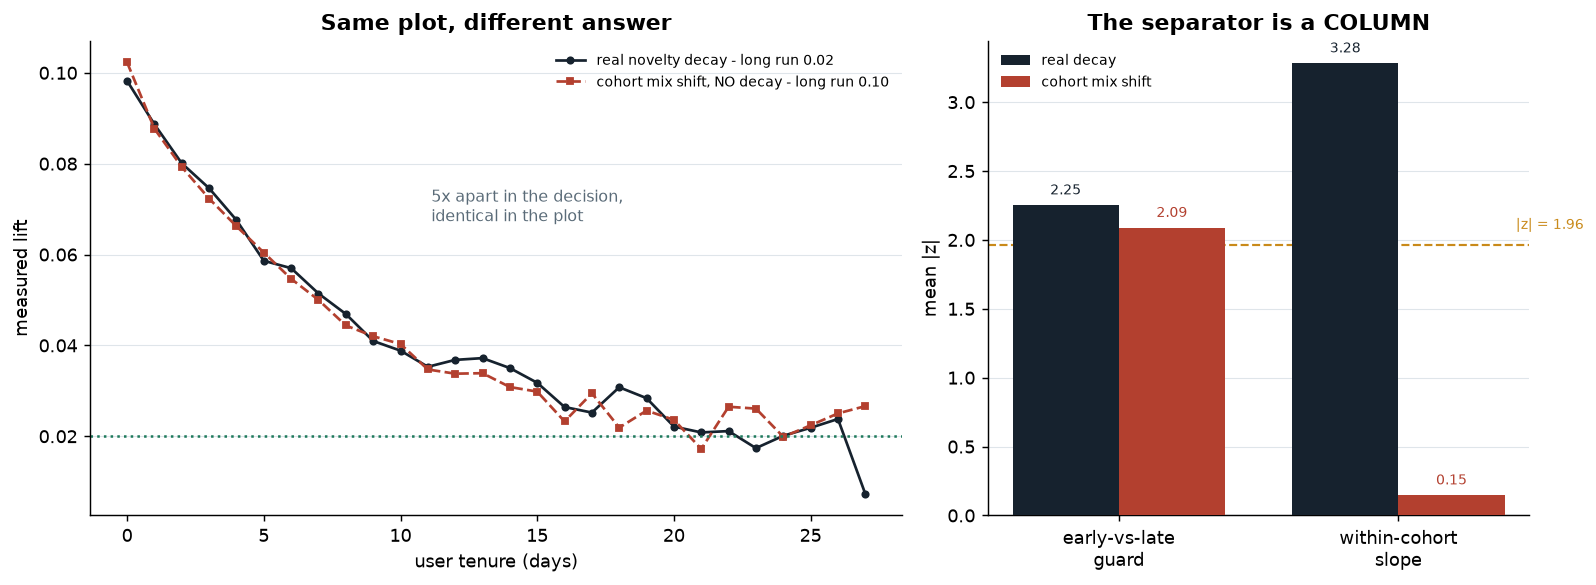

In [8]:
import matplotlib.pyplot as plt

INK, BAD, GOOD, WARN, GRID = "#16222e", "#b3402f", "#1f7a5c", "#c98a1a", "#dfe5ea"
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 4.6), dpi=130,
                               gridspec_kw={"width_ratios": [1.5, 1]})

ax1.plot(np.arange(T), cd, "o-", color=INK, ms=3.5, lw=1.5,
         label=f"real novelty decay - long run {TAU_INF:.2f}")
ax1.plot(np.arange(T), cm, "s--", color=BAD, ms=3.5, lw=1.5,
         label=f"cohort mix shift, NO decay - long run {m.mean():.2f}")
ax1.axhline(TAU_INF, color=GOOD, ls=":", lw=1.4)
ax1.annotate(f"{m.mean() / TAU_INF:.0f}x apart in the decision,\nidentical in the plot",
             (0.42, 0.62), xycoords="axes fraction", fontsize=9, color="#5a6b78")
ax1.set_xlabel("user tenure (days)"); ax1.set_ylabel("measured lift")
ax1.set_title("Same plot, different answer", fontweight="bold")
ax1.legend(fontsize=8, frameon=False)

x = np.arange(2)
ax2.bar(x - 0.19, [abs(gz["decay"]), abs(sz["decay"])], 0.38, color=INK,
        label="real decay", zorder=3)
ax2.bar(x + 0.19, [abs(gz["mix"]), abs(sz["mix"])], 0.38, color=BAD,
        label="cohort mix shift", zorder=3)
for xi, v in zip(x - 0.19, [abs(gz["decay"]), abs(sz["decay"])]):
    ax2.annotate(f"{v:.2f}", (xi, v + 0.08), ha="center", fontsize=8, color=INK)
for xi, v in zip(x + 0.19, [abs(gz["mix"]), abs(sz["mix"])]):
    ax2.annotate(f"{v:.2f}", (xi, v + 0.08), ha="center", fontsize=8, color=BAD)
ax2.axhline(1.96, color=WARN, ls="--", lw=1.2)
ax2.annotate("|z| = 1.96", (1.42, 2.08), fontsize=8, color=WARN)
ax2.set_xticks(x)
ax2.set_xticklabels(["early-vs-late\nguard", "within-cohort\nslope"])
ax2.set_ylabel("mean |z|")
ax2.set_title("The separator is a COLUMN", fontweight="bold")
ax2.legend(fontsize=8, frameon=False)

for ax in (ax1, ax2):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.grid(axis="y", color=GRID, lw=0.6)
    ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig("novelty_notebook_figure.png", bbox_inches="tight")
plt.show()

## 7. Survivorship: the same estimator fails upward

Flip the mechanism. A permanent effect, no cohort structure - but the treatment drives
*low-value* users away. The treated survivors are increasingly the high-value ones, so the
measured lift **grows** with tenure and reads as "the effect compounds, ship it and expect
more". The truth is that the feature is destroying users.

Then check the obvious guard: compare retention between the arms.

In [9]:
def panel_survivor(rng, n_users=8400, T=T, tau=0.05, h0=0.03, gamma=0.8, sigma=1.0):
    s, tenure, obs = skeleton(n_users, T, "bigbang")
    w = (rng.random(n_users) < 0.5).astype(np.int8)
    base = rng.normal(0.0, 1.0, n_users)
    haz = np.where(w == 1, h0 * np.exp(-gamma * base), h0)   # treated: low value churns fast
    churned = rng.random((n_users, T)) < haz[:, None]
    first = np.where(churned.any(1), churned.argmax(1), T)
    obs = obs & (np.arange(T)[None, :] < first[:, None])
    y = base[:, None] + w[:, None] * tau + rng.normal(0.0, sigma, (n_users, T))
    return {"y": np.where(obs, y, np.nan), "w": w, "s": s,
            "tenure": np.where(obs, tenure, -1), "obs": obs, "T": T,
            "truth_long_run": tau, "alive": obs}


rng = np.random.default_rng(61)
TAU_S = 0.05
cs = np.zeros(T); pool, rt, rc, rz = [], [], [], []
for _ in range(100):
    dd = panel_survivor(rng, tau=TAU_S)
    c = lift_by_tenure(dd, min_arm=20)
    cs[c["tenure"].astype(int)] += c["lift"]
    pool.append(pooled_lift(dd)[0])
    a = dd["alive"]
    at, ac = a[dd["w"] == 1][:, -1].mean(), a[dd["w"] == 0][:, -1].mean()
    nt, nc = int((dd["w"] == 1).sum()), int((dd["w"] == 0).sum())
    rt.append(at); rc.append(ac)
    rz.append((at - ac) / np.sqrt(at * (1 - at) / nt + ac * (1 - ac) / nc))
cs /= 100

print(f"a PERMANENT effect of {TAU_S}, no decay and no cohort structure anywhere")
print()
print(f"{'tenure':>8} {'measured lift':>14} {'x truth':>9}")
for t in (0, 3, 7, 14, 21, 27):
    print(f"{t:>8} {cs[t]:>14.4f} {cs[t] / TAU_S:>8.1f}x")
print()
print(f"pooled lift {np.mean(pool):.4f} against a truth of {TAU_S} - "
      f"{np.mean(pool) / TAU_S:.1f}x, with a POSITIVE slope")
print()
print(f"retention at day {T - 1}: treated {np.mean(rt):.4f}, control {np.mean(rc):.4f}, "
      f"diff {np.mean(rt) - np.mean(rc):+.4f}")
print(f"the retention check fires in {float(np.mean(np.abs(rz) > 1.96)):.3f} of runs "
      f"(mean |z| = {abs(np.mean(rz)):.2f})")
print()
print("The obvious guard is nearly inert. The mechanism is COMPOSITIONAL: the treatment sheds")
print("low-value users and keeps high-value ones, and the two flows almost cancel in the")
print("headcount while doing all the damage to the mean. Counting users cannot see a change")
print("in WHO they are.")

a PERMANENT effect of 0.05, no decay and no cohort structure anywhere

  tenure  measured lift   x truth
       0         0.0860      1.7x
       3         0.1733      3.5x
       7         0.2679      5.4x
      14         0.4095      8.2x
      21         0.5165     10.3x
      27         0.6017     12.0x

pooled lift 0.3431 against a truth of 0.05 - 6.9x, with a POSITIVE slope

retention at day 27: treated 0.4215, control 0.4261, diff -0.0045
the retention check fires in 0.080 of runs (mean |z| = 0.42)

The obvious guard is nearly inert. The mechanism is COMPOSITIONAL: the treatment sheds
low-value users and keeps high-value ones, and the two flows almost cancel in the
headcount while doing all the damage to the mean. Counting users cannot see a change
in WHO they are.


## 8. What the fix costs

The recommended answer is a long-term holdout. Its resolution is arithmetic: the MDE at
allocation `p` relative to a 50/50 test is $1/(2\sqrt{p(1-p)})$ - no `n`, no `sigma`.

And a single holdout carrying several launches is a **joint cost**. The daily gap is a sum of
step functions, so whether one launch's share is recoverable is decided by the release
calendar, before any data exists.

In [10]:
def mde_ratio(p):
    return float(1 / (2 * np.sqrt(p * (1 - p))))


print(f"{'holdout share':>14} {'MDE x 50/50':>12} {'traffic-time to match':>22}")
print("-" * 50)
for p in (0.50, 0.20, 0.10, 0.05, 0.01):
    print(f"{p:>14.0%} {mde_ratio(p):>12.3f} {mde_ratio(p) ** 2:>21.1f}x")
print()
print(f"A 5% holdout carries {mde_ratio(0.05):.2f}x the MDE of the test that shipped the feature,")
print(f"and must resolve a SMALLER quantity (tau_inf/tau0 = {TAU_INF / TAU0:.2f}), so matching the")
print(f"original power takes {(mde_ratio(0.05) * TAU0 / TAU_INF) ** 2:.0f}x the user-days.")
print()


def holdout_attribution(ship_days, n_days, gap_se):
    """None when the calendar leaves the per-launch effects unidentified."""
    dd = np.arange(n_days)
    X = np.column_stack([(dd >= s).astype(float) for s in np.asarray(ship_days)])
    if np.linalg.matrix_rank(X) < X.shape[1]:
        return None
    inv = np.linalg.inv(X.T @ X)
    ones = np.ones(X.shape[1])
    return {"se_per_launch": gap_se * np.sqrt(np.diag(inv)),
            "se_total": gap_se * float(np.sqrt(ones @ inv @ ones))}


gap_se = np.sqrt(1 / 10000 + 1 / 190000)   # 200k users, a 5% holdout
ded = np.sqrt(2 / 100000)                  # a dedicated 50/50 test on 100k
print(f"{'release calendar':>30} {'SE per launch':>14} {'SE of total':>12} {'x dedicated':>12}")
print("-" * 72)
for g in (30, 14, 7, 3, 1, 0):
    a = holdout_attribution(30 + np.arange(6) * g, 240, gap_se)
    lab = f"6 launches, {g} days apart" if g else "6 launches, all the same day"
    if a is None:
        print(f"{lab:>30} {'UNIDENTIFIED':>14} {'--':>12} {'--':>12}")
    else:
        per = float(np.mean(a["se_per_launch"]))
        print(f"{lab:>30} {per:>14.5f} {a['se_total']:>12.5f} {per / ded:>11.2f}x")
print()
print("Attribution is nearly FREE while the launches are separable - and then falls off a")
print("cliff. On the same day the per-launch effects are not identified at ANY sample size,")
print("because the design matrix loses RANK rather than becoming imprecise. There is no")
print("gradient to manage at the end, and which side you are on is computable from the ship")
print("dates alone.")

 holdout share  MDE x 50/50  traffic-time to match
--------------------------------------------------
           50%        1.000                   1.0x
           20%        1.250                   1.6x
           10%        1.667                   2.8x
            5%        2.294                   5.3x
            1%        5.025                  25.3x

A 5% holdout carries 2.29x the MDE of the test that shipped the feature,
and must resolve a SMALLER quantity (tau_inf/tau0 = 0.20), so matching the
original power takes 132x the user-days.

              release calendar  SE per launch  SE of total  x dedicated
------------------------------------------------------------------------
     6 launches, 30 days apart        0.00246      0.00132        0.55x
     6 launches, 14 days apart        0.00352      0.00087        0.79x
      6 launches, 7 days apart        0.00496      0.00078        1.11x
      6 launches, 3 days apart        0.00757      0.00073        1.69x
      6 launches, 1

## 9. So which wrong number do you ship on?

Four defensible policies, scored against the long-run truth. The bias-variance split is the
whole decision, and it is not a tie.

In [11]:
rng = np.random.default_rng(81)
pol = {"pooled 4-week lift": [], "final-week lift": [], "fitted asymptote": [],
       "5% holdout, 12 weeks": []}
for _ in range(100):
    dd = panel_decay(rng, T=28)
    pol["pooled 4-week lift"].append(pooled_lift(dd)[0])
    pol["final-week lift"].append(window_lift(dd, 21, 28)[0])
    f = fit_exponential(lift_by_tenure(dd))
    if f is not None:
        pol["fitted asymptote"].append(f["tau_inf"])
    hd = panel_decay(rng, n_users=8400, T=84, enroll="bigbang", p_treat=0.95)   # 95/5
    pol["5% holdout, 12 weeks"].append(window_lift(hd, 56, 84)[0])

print(f"{'policy':>22} {'mean claim':>11} {'bias':>9} {'sd':>8} {'RMSE':>8} {'x truth':>8}")
print("-" * 70)
for k, v in pol.items():
    a = np.array(v)
    print(f"{k:>22} {a.mean():>11.4f} {a.mean() - TAU_INF:>9.4f} {a.std(ddof=1):>8.4f} "
          f"{np.sqrt(np.mean((a - TAU_INF) ** 2)):>8.4f} {a.mean() / TAU_INF:>7.2f}x")
print()
print("The window readouts are precise and wrong by a factor. The fitted asymptote is both")
print("biased and far noisier than the readout it replaces. The underpowered holdout is the")
print("only one that is centred, and it costs three months. There is no readout of a")
print("four-week test that answers the question - the pooled lift, the default, is simply the")
print("one that is confidently wrong.")

                policy  mean claim      bias       sd     RMSE  x truth
----------------------------------------------------------------------
    pooled 4-week lift      0.0516    0.0316   0.0065   0.0323    2.58x
       final-week lift      0.0222    0.0022   0.0223   0.0223    1.11x
      fitted asymptote     -0.0321   -0.0521   0.1946   0.2005   -1.60x
  5% holdout, 12 weeks      0.0207    0.0007   0.0098   0.0098    1.04x

The window readouts are precise and wrong by a factor. The fitted asymptote is both
biased and far noisier than the readout it replaces. The underpowered holdout is the
only one that is centred, and it costs three months. There is no readout of a
four-week test that answers the question - the pooled lift, the default, is simply the
one that is confidently wrong.


## 10. Try your own

Change the world and see which readouts survive.

In [12]:
# --- 1. how fast does novelty have to decay before your window is lying to you?
# for lam in (1, 3, 7, 14, 28):
#     A = attenuation(28, lam, "uniform")
#     print(f"lam={lam:>3}  reported {TAU_INF + (TAU0 - TAU_INF) * A:.4f}  "
#           f"({(TAU_INF + (TAU0 - TAU_INF) * A) / TAU_INF:.1f}x the truth)")

# --- 2. does the within-cohort separator still work with fewer users per cohort?
# for n in (2800, 5600, 8400, 16800):
#     rng = np.random.default_rng(1)
#     print(n, within_cohort_slope(panel_decay(rng, n_users=(n // 28) * 28)))

# --- 3. your own release calendar: is one launch's share recoverable?
# my_ships = [10, 12, 40, 41, 90]          # <- put real ship days here
# a = holdout_attribution(my_ships, 240, gap_se)
# print("UNIDENTIFIED" if a is None else a["se_per_launch"] / ded)

# --- 4. what if the effect GROWS (primacy rather than novelty)?
# rng = np.random.default_rng(5)
# d_grow = panel_decay(rng, tau0=0.02, tau_inf=0.10, lam=7.0)
# print(pooled_lift(d_grow), "truth", d_grow["truth_long_run"])
print("uncomment a block above and re-run")

uncomment a block above and re-run


---

## What to take away

1. **A measured lift is a lift at an age.** The first-day, pooled and final-week readouts of
   one 28-day test span a factor of 5, and none of them estimates the long-run effect.
2. **The enrollment process is part of the readout.** Continuous enrollment keeps the
   population young and weights novelty *up* by up to 1.8x versus big-bang - a property of
   the release calendar with no data in it, and the opposite of the usual intuition.
3. **A decaying lift is not evidence the effect decayed.** A permanent per-cohort effect
   produces the identical curve, with a long-run answer 5x larger. The published plot cannot
   separate them at any sample size; the enrollment *column* can.
4. **Survivorship makes the same estimator fail upward**, and the retention check that looks
   like the natural guard is nearly blind to it, because the mechanism changes who the users
   are rather than how many.
5. **The fitted asymptote is trustworthy only when it is unnecessary**, and its $R^2$ ranks
   the windows backwards.
6. **The holdout is the honest fix and it is expensive**: 2.29x the MDE at a 5% slice, ~130x
   the user-days to match the original power, and a per-launch split that the release calendar
   either permits or forbids outright.

The general shape, which is the reusable part: **when a readout is a function of an exposure
distribution, changing the distribution changes the readout - so a number that moved is
evidence about the distribution, not yet about the effect.**

**Where this sits in the portfolio** - the non-randomised and post-hoc half of the
experimentation series:
[`peeking-cost`](../peeking-cost/) (the stopping rule is part of the test),
[`srm-detector`](../srm-detector/) (a passing guard is not evidence),
[`cuped-variance`](../cuped-variance/) (variance reduction as a bet on a correlation),
[`diff-in-diff`](../diff-in-diff/) (parallel trends when you could not randomise),
[`interference-check`](../interference-check/) (a split measures a transfer between arms),
[`synthetic-control`](../synthetic-control/) (the control group as a fitted object) and
[`heterogeneous-effects`](../heterogeneous-effects/) (a segment you found is not one you named).

**The full build:**
- `python evidence.py` - the eight-section measurement, ~85s
- `python -m pytest test_novelty.py test_app.py` - 33 assertions behind every number
- `streamlit run app.py` - pick a world, read the plot, then read what the plot cannot say
- `python make_chart.py` - the six-panel figure

**Reading, for the results this build re-derives rather than cites:** Hohnhold, O'Brien &
Tang (2015) on learning effects and long-term holdbacks at Google; Kohavi, Tang & Xu (2020),
*Trustworthy Online Controlled Experiments*, on novelty/primacy and holdout design; Dmitriev
et al. (2017) on misinterpreted metric movements; Chen, Liu & Xu (2019) on long-term effect
estimation via surrogates.

[Back to the portfolio index](https://github.com/phoebefu6/phoebe-the-builder)